# STEP 06 — OpenMx vs NPE Comparison

Compares the classical SEM estimator (OpenMx, STEP 04) against the neural
posterior estimator (STEP 05) on the *same* test conditions.

## The pipeline

| Step | Script | Produces |
|---|---|---|
| 01 | `01_generate_training_data.py` | `data/ace_training_data*.csv` |
| 02 | `02_train_npe.py` | `results/models/<run>/` |
| 03 | `03_evaluate_oos_predictions.py` | `results/oos/<run>/` |
| 04 | `04_fit_openmx_reference.R` | `data/ace_test_conditions.csv`, `results/simulations/ace_simulation_results.csv` |
| 05 | `05_simulate_posterior_recovery.py` | `results/simulations/npe_simulation_results*.csv` |
| 06 | this notebook | `results/analysis/` |

Every figure and table this notebook produces is written to
**`results/analysis/`** via the `save_fig` / `save_table` helpers below —
nothing is written next to the scripts.


In [10]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ace_model.py is the shared library; it also owns the folder layout.
sys.path.insert(0, str(Path.cwd()))
from ace_model import SIM_DIR, ANALYSIS_DIR

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Write a figure to results/analysis/ and report the path."""
    path = ANALYSIS_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"  figure -> {path.relative_to(ANALYSIS_DIR.parents[1])}")
    return path


def save_table(df, name):
    """Write a summary table to results/analysis/ and report the path."""
    path = ANALYSIS_DIR / f"{name}.csv"
    df.to_csv(path)
    print(f"  table  -> {path.relative_to(ANALYSIS_DIR.parents[1])}")
    return path


# -- Load the two estimators' simulation results -----------------------------
omx      = pd.read_csv(SIM_DIR / "ace_simulation_results.csv")
npe      = pd.read_csv(SIM_DIR / "npe_simulation_results.csv")
npe_no_n = pd.read_csv(SIM_DIR / "npe_simulation_results_no_n.csv")

# Keep only converged OpenMx fits
omx = omx[omx["converged"] == 1].copy()

print(f"OpenMx rows (converged): {len(omx)}")
print(f"NPE rows (with N):       {len(npe)}")
print(f"NPE rows (no N):         {len(npe_no_n)}")
print(f"Sample sizes:            {sorted(omx['sample_size'].unique())}")
print(f"Output directory:        {ANALYSIS_DIR}")


OpenMx rows (converged): 1389
NPE rows (with N):       1400
NPE rows (no N):         1400
Sample sizes:            [np.int64(50), np.int64(100), np.int64(200), np.int64(500), np.int64(1000), np.int64(2000), np.int64(20000)]
Output directory:        /Users/xuly4739/Library/CloudStorage/OneDrive-UCB-O365/Documents/coding/PyProject/PGS_Cor_Relative/Scripts/nn_validate/ace_npe/results/analysis


In [11]:
# -- Aggregate statistics ----------------------------------------------------
SAMPLE_SIZES = sorted(omx["sample_size"].unique())
PARAMS = ["A", "C", "E"]
xs = np.array(SAMPLE_SIZES)


def aggregate(df, stat_fn, col_template):
    """Group by sample_size, apply stat_fn to each parameter column."""
    records = []
    for n in SAMPLE_SIZES:
        sub = df[df["sample_size"] == n]
        row = {"sample_size": n}
        for p in PARAMS:
            row[p] = stat_fn(sub[col_template.format(p)].dropna())
        records.append(row)
    return pd.DataFrame(records).set_index("sample_size")


def bias_frame(df, est_template="{}_est"):
    """Attach per-row bias columns (estimate - truth) for each parameter."""
    return df.assign(**{
        f"{p}_bias": df[est_template.format(p)] - df[f"true_{p}"]
        for p in PARAMS
    })


def bias_se(x):
    """SE of the mean bias estimate."""
    x = x.dropna()
    return np.std(x, ddof=1) / np.sqrt(len(x))


# Empirical SD of estimates, and mean reported SE, across conditions
omx_var_est      = aggregate(omx,      np.std,  "{}_est")
npe_var_est      = aggregate(npe,      np.std,  "{}_est")
npe_no_n_var_est = aggregate(npe_no_n, np.std,  "{}_est")

omx_mean_se      = aggregate(omx,      np.mean, "{}_se")
npe_mean_se      = aggregate(npe,      np.mean, "{}_se")
npe_no_n_mean_se = aggregate(npe_no_n, np.mean, "{}_se")

# Bias of the point estimate (posterior mean for NPE, MLE for OpenMx)
omx_bias         = aggregate(bias_frame(omx),      np.mean, "{}_bias")
omx_bias_se      = aggregate(bias_frame(omx),      bias_se, "{}_bias")
npe_bias         = aggregate(bias_frame(npe),      np.mean, "{}_bias")
npe_bias_se      = aggregate(bias_frame(npe),      bias_se, "{}_bias")
npe_no_n_bias    = aggregate(bias_frame(npe_no_n), np.mean, "{}_bias")
npe_no_n_bias_se = aggregate(bias_frame(npe_no_n), bias_se, "{}_bias")

# Bias of the NPE MAP estimate (no-N model)
npe_no_n_map_bias    = aggregate(bias_frame(npe_no_n, "{}_map"), np.mean, "{}_bias")
npe_no_n_map_bias_se = aggregate(bias_frame(npe_no_n, "{}_map"), bias_se, "{}_bias")

print("Empirical SD of estimates (OpenMx):")
print(omx_var_est.round(6))
print("\nEmpirical SD of estimates (NPE, with N):")
print(npe_var_est.round(6))


Empirical SD of estimates (OpenMx):
                    A         C         E
sample_size                              
50           0.251483  0.256613  0.236645
100          0.244243  0.256238  0.244953
200          0.244078  0.244702  0.235260
500          0.231303  0.244240  0.233281
1000         0.233388  0.243044  0.233571
2000         0.233569  0.242007  0.233704
20000        0.228081  0.239573  0.232747

Empirical SD of estimates (NPE, with N):
                    A         C         E
sample_size                              
50           0.188036  0.216861  0.237617
100          0.213663  0.218379  0.233941
200          0.218009  0.219225  0.236400
500          0.225802  0.235916  0.233820
1000         0.227237  0.232646  0.233378
2000         0.234190  0.238147  0.234036
20000        0.231611  0.235886  0.235112


In [12]:
# -- Persist every aggregate table to results/analysis/ ----------------------
TABLES = {
    "sd_of_estimates_openmx":     omx_var_est,
    "sd_of_estimates_npe":        npe_var_est,
    "sd_of_estimates_npe_no_n":   npe_no_n_var_est,
    "mean_se_openmx":             omx_mean_se,
    "mean_se_npe":                npe_mean_se,
    "mean_se_npe_no_n":           npe_no_n_mean_se,
    "bias_openmx":                omx_bias,
    "bias_npe":                   npe_bias,
    "bias_npe_no_n":              npe_no_n_bias,
    "bias_npe_no_n_map":          npe_no_n_map_bias,
}

print("Saving aggregate tables:")
for name, table in TABLES.items():
    save_table(table.round(8), name)

# One tidy long-format table combining every estimator, for downstream use.
long_rows = []
for estimator, bias_df, se_df, sd_df in [
    ("openmx",       omx_bias,          omx_mean_se,      omx_var_est),
    ("npe_with_n",   npe_bias,          npe_mean_se,      npe_var_est),
    ("npe_no_n",     npe_no_n_bias,     npe_no_n_mean_se, npe_no_n_var_est),
    ("npe_no_n_map", npe_no_n_map_bias, npe_no_n_mean_se, npe_no_n_var_est),
]:
    for n in SAMPLE_SIZES:
        for p in PARAMS:
            long_rows.append({
                "estimator":   estimator,
                "sample_size": n,
                "parameter":   p,
                "bias":        bias_df.loc[n, p],
                "mean_se":     se_df.loc[n, p],
                "sd_of_est":   sd_df.loc[n, p],
            })

summary_long = pd.DataFrame(long_rows)
save_table(summary_long.set_index(["estimator", "sample_size", "parameter"]),
           "summary_long")
summary_long.head()


Saving aggregate tables:
  table  -> results/analysis/sd_of_estimates_openmx.csv
  table  -> results/analysis/sd_of_estimates_npe.csv
  table  -> results/analysis/sd_of_estimates_npe_no_n.csv
  table  -> results/analysis/mean_se_openmx.csv
  table  -> results/analysis/mean_se_npe.csv
  table  -> results/analysis/mean_se_npe_no_n.csv
  table  -> results/analysis/bias_openmx.csv
  table  -> results/analysis/bias_npe.csv
  table  -> results/analysis/bias_npe_no_n.csv
  table  -> results/analysis/bias_npe_no_n_map.csv
  table  -> results/analysis/summary_long.csv


,estimator,sample_size,parameter,bias,mean_se,sd_of_est
0,openmx,50,A,-0.015688,0.217016,0.251483
1,openmx,50,C,0.019668,0.190913,0.256613
2,openmx,50,E,-0.003979,0.062384,0.236645
3,openmx,100,A,-0.003060,0.155936,0.244243
4,openmx,100,C,0.001984,0.136873,0.256238


In [13]:
# -- Plot settings -----------------------------------------------------------
OMX_COLOR  = "#2196F3"   # blue
NPE_COLOR  = "#F44336"   # red
NO_N_COLOR = "#4CAF50"   # green
MAP_COLOR  = "#FF9800"   # orange
MARKER, LW, MS = "o", 2.0, 6

PARAM_LABELS = {"A": "A (additive genetic)",
                "C": "C (shared environment)",
                "E": "E (unique environment)"}


def sample_size_axis(ax):
    """Shared log-x formatting for the sample-size axis."""
    ax.set_xlabel("Sample size (N pairs)", fontsize=10)
    ax.set_xscale("log")
    ax.set_xticks(xs)
    ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.35, linestyle=":")


def precision_panel(series_specs, title, filename):
    """Row 1 = empirical SD of estimates, row 2 = mean reported SE."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)

    for row, (metric_label, tables) in enumerate([
        ("SD of $\\hat{%s}$", [(lbl, sd, c, ls) for lbl, sd, _, c, ls in series_specs]),
        ("Mean SE of $%s$",     [(lbl, se, c, ls) for lbl, _, se, c, ls in series_specs]),
    ]):
        for col, param in enumerate(PARAMS):
            ax = axes[row, col]
            for label, table, color, ls in tables:
                ax.plot(xs, table[param].values, color=color, marker=MARKER,
                        linewidth=LW, markersize=MS, linestyle=ls, label=label)
            head = "SD of" if row == 0 else "Mean SE of"
            ax.set_title(f"{head} {PARAM_LABELS[param]}", fontsize=11, fontweight="bold")
            ax.set_ylabel(metric_label % param, fontsize=10)
            sample_size_axis(ax)

    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()


def bias_panel(specs, title, filename, figsize=(14, 8)):
    """One row per estimator; mean bias with a 95% CI ribbon."""
    fig, axes = plt.subplots(len(specs), 3, figsize=figsize, sharey=False)
    axes = np.atleast_2d(axes)
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for row, (label, bias_df, se_df, color) in enumerate(specs):
        for col, param in enumerate(PARAMS):
            ax   = axes[row, col]
            bias = bias_df[param].values
            ci   = 1.96 * se_df[param].values

            ax.axhline(0, color="black", linewidth=1.2, linestyle="--", zorder=1)
            ax.fill_between(xs, bias - ci, bias + ci, color=color, alpha=0.18,
                            label="95% CI")
            ax.plot(xs, bias, color=color, marker=MARKER, linewidth=LW,
                    markersize=MS, label=f"{label} mean bias", zorder=3)

            if row == 0:
                ax.set_title(PARAM_LABELS[param], fontsize=11, fontweight="bold")
            ax.set_ylabel(f"{label}\nBias of $\\hat{{{param}}}$", fontsize=9)
            sample_size_axis(ax)

    plt.tight_layout()
    save_fig(fig, filename)
    plt.show()


  figure -> results/analysis/precision_openmx_vs_npe.png


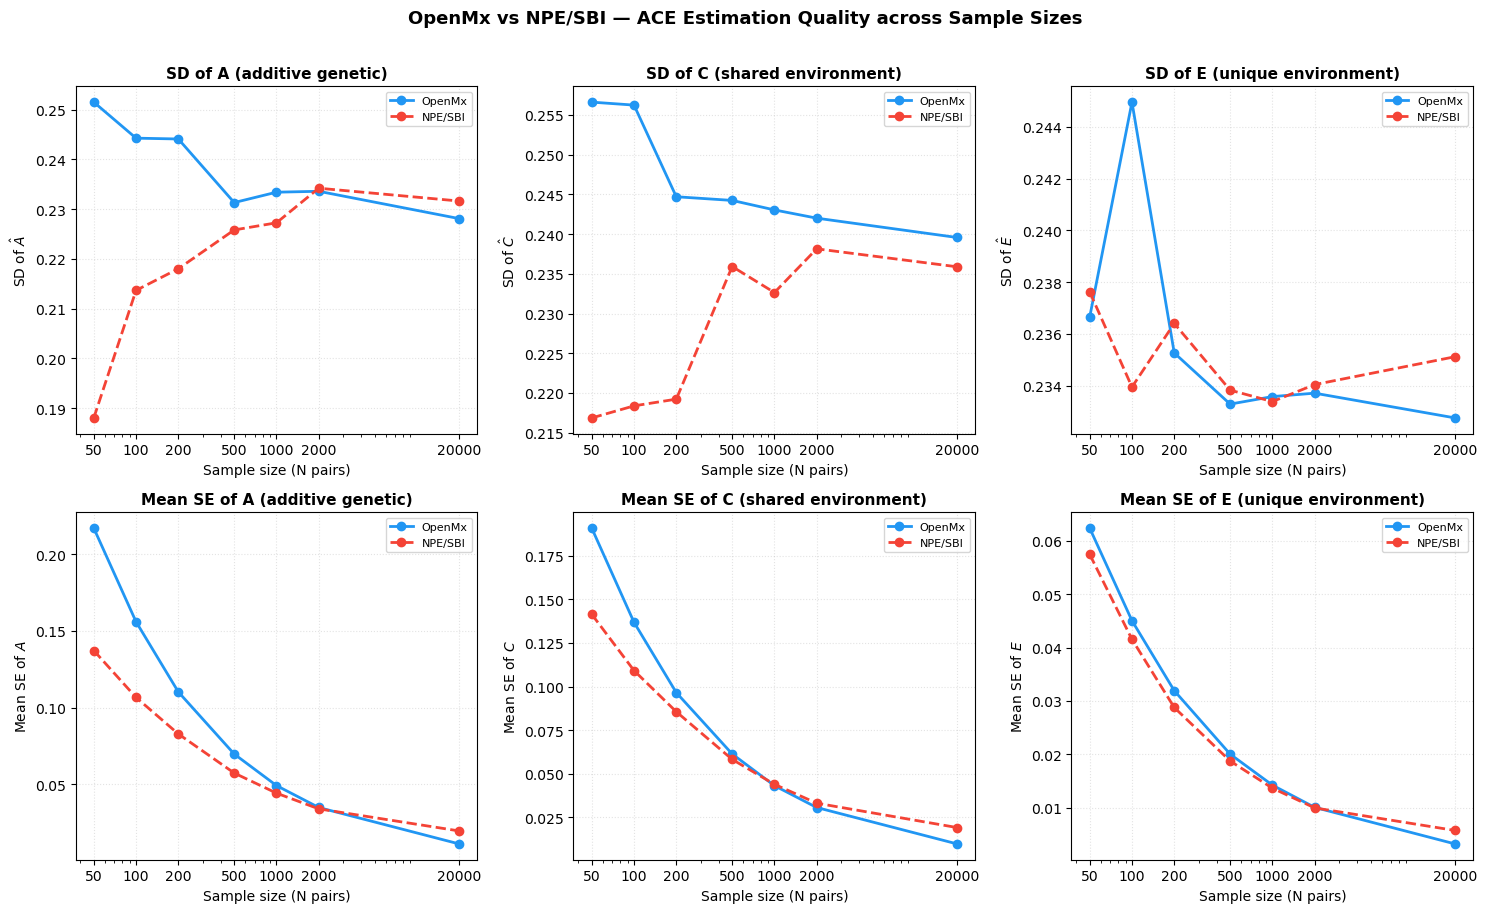

In [14]:
# -- OpenMx vs NPE (with N): precision --------------------------------------
precision_panel(
    [
        ("OpenMx",  omx_var_est, omx_mean_se, OMX_COLOR, "-"),
        ("NPE/SBI", npe_var_est, npe_mean_se, NPE_COLOR, "--"),
    ],
    "OpenMx vs NPE/SBI — ACE Estimation Quality across Sample Sizes",
    "precision_openmx_vs_npe",
)


NPE mean bias (est - true) by sample size

                  A       C       E
sample_size                        
50           0.0143  0.0221  0.0077
100          0.0100  0.0078  0.0052
200         -0.0067  0.0138  0.0035
500          0.0044 -0.0016  0.0005
1000        -0.0020  0.0020 -0.0001
2000         0.0019 -0.0039 -0.0007
20000       -0.0036  0.0020  0.0004

OpenMx mean bias (est - true) by sample size

                  A       C       E
sample_size                        
50          -0.0157  0.0197 -0.0040
100         -0.0031  0.0020  0.0011
200         -0.0062  0.0042  0.0020
500          0.0041 -0.0034 -0.0007
1000         0.0017 -0.0001 -0.0017
2000         0.0008  0.0001 -0.0010
20000        0.0003 -0.0004  0.0001
  figure -> results/analysis/bias_openmx_vs_npe.png


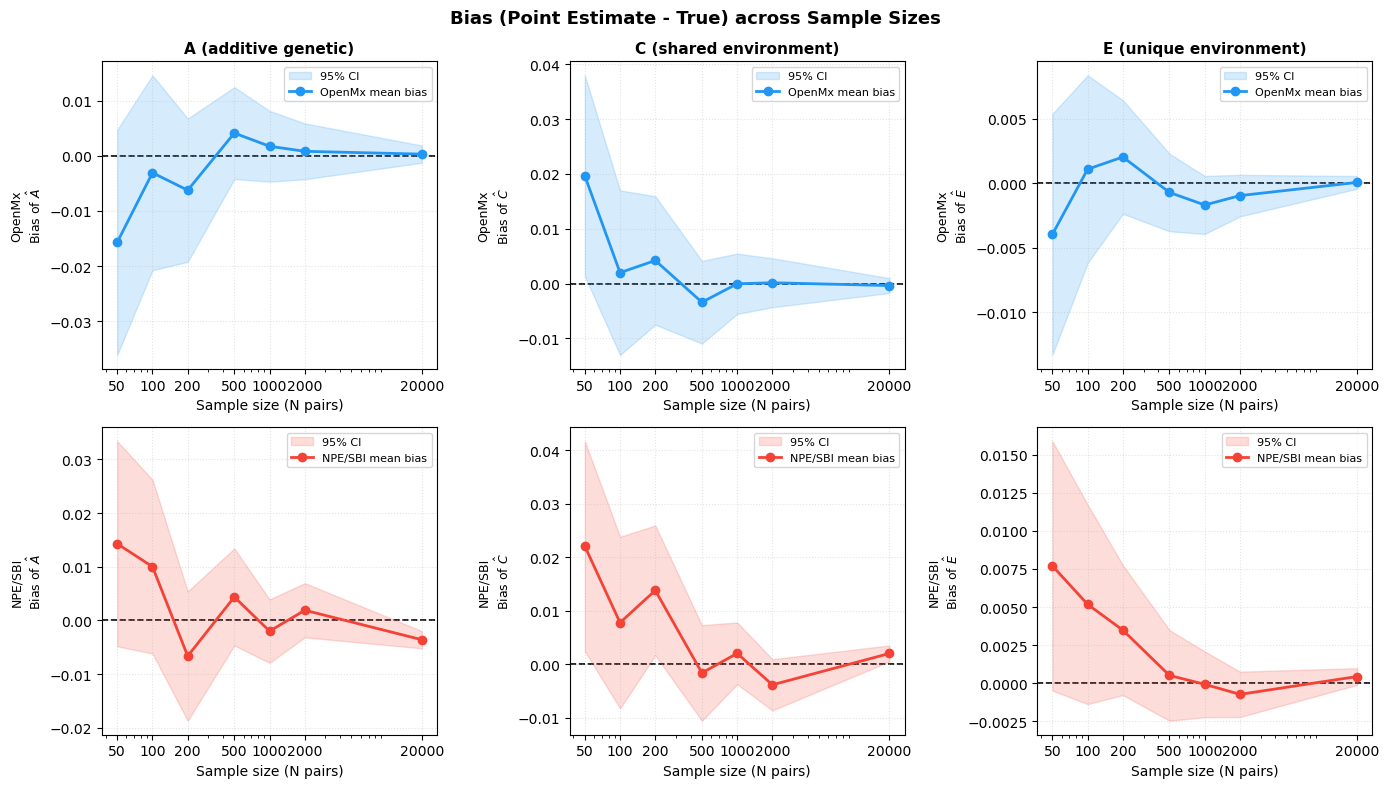

In [15]:
# -- OpenMx vs NPE (with N): bias -------------------------------------------
print("NPE mean bias (est - true) by sample size\n")
print(npe_bias.round(4).to_string())
print("\nOpenMx mean bias (est - true) by sample size\n")
print(omx_bias.round(4).to_string())

bias_panel(
    [
        ("OpenMx",  omx_bias, omx_bias_se, OMX_COLOR),
        ("NPE/SBI", npe_bias, npe_bias_se, NPE_COLOR),
    ],
    "Bias (Point Estimate - True) across Sample Sizes",
    "bias_openmx_vs_npe",
)


  figure -> results/analysis/precision_three_way.png


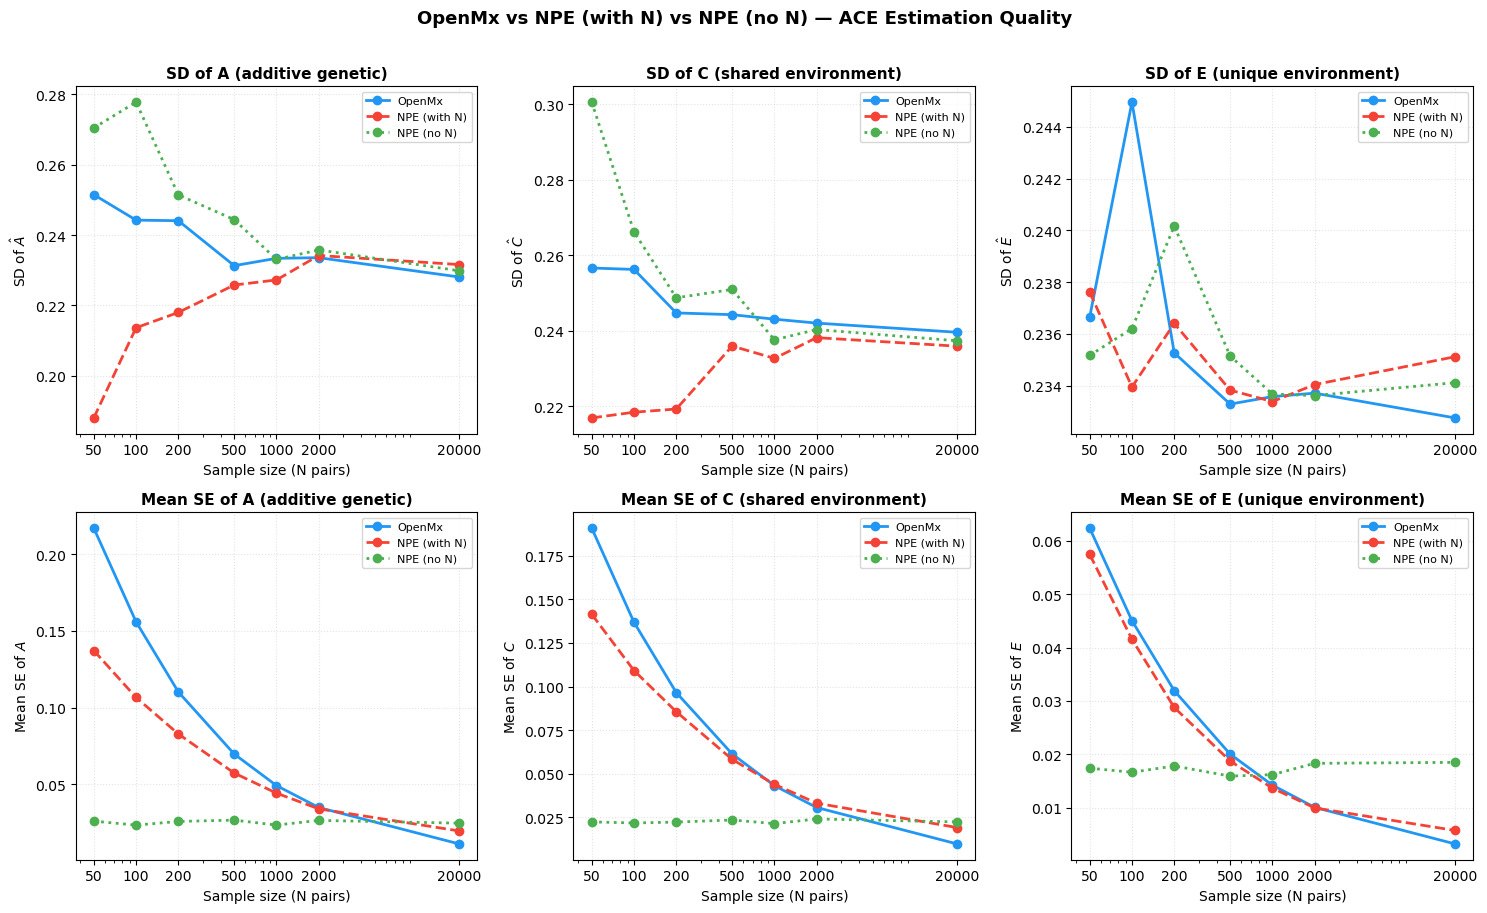

In [16]:
# -- Three-way: OpenMx vs NPE (with N) vs NPE (no N) ------------------------
precision_panel(
    [
        ("OpenMx",       omx_var_est,      omx_mean_se,      OMX_COLOR,  "-"),
        ("NPE (with N)", npe_var_est,      npe_mean_se,      NPE_COLOR,  "--"),
        ("NPE (no N)",   npe_no_n_var_est, npe_no_n_mean_se, NO_N_COLOR, ":"),
    ],
    "OpenMx vs NPE (with N) vs NPE (no N) — ACE Estimation Quality",
    "precision_three_way",
)


NPE (no-N) mean bias (est - true) by sample size

                  A       C       E
sample_size                        
50           0.0079  0.0110 -0.0023
100          0.0017  0.0028  0.0015
200         -0.0121  0.0139  0.0025
500          0.0072 -0.0039 -0.0005
1000        -0.0007  0.0037 -0.0014
2000         0.0059 -0.0039 -0.0024
20000        0.0022  0.0006 -0.0012
  figure -> results/analysis/bias_three_way.png


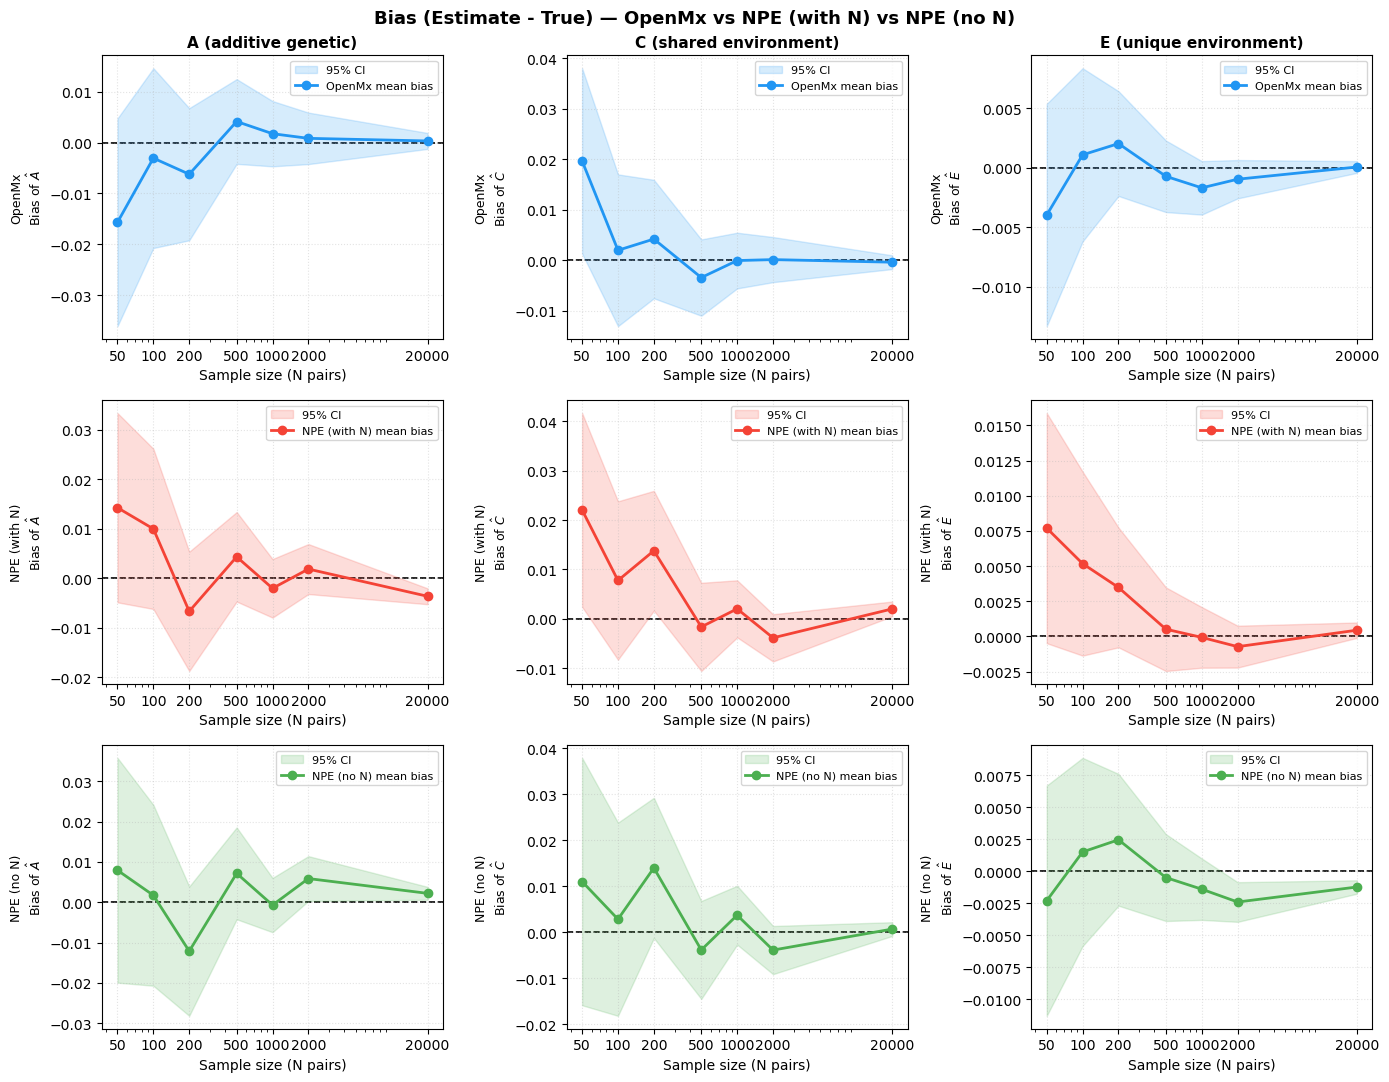

In [17]:
# -- Three-way bias comparison ----------------------------------------------
print("NPE (no-N) mean bias (est - true) by sample size\n")
print(npe_no_n_bias.round(4).to_string())

bias_panel(
    [
        ("OpenMx",       omx_bias,      omx_bias_se,      OMX_COLOR),
        ("NPE (with N)", npe_bias,      npe_bias_se,      NPE_COLOR),
        ("NPE (no N)",   npe_no_n_bias, npe_no_n_bias_se, NO_N_COLOR),
    ],
    "Bias (Estimate - True) — OpenMx vs NPE (with N) vs NPE (no N)",
    "bias_three_way",
    figsize=(14, 11),
)


NPE (no-N) MAP bias (MAP - true) by sample size

                  A       C       E
sample_size                        
50           0.0077  0.0115 -0.0024
100          0.0014  0.0031  0.0015
200         -0.0127  0.0141  0.0026
500          0.0068 -0.0040 -0.0005
1000        -0.0012  0.0035 -0.0014
2000         0.0054 -0.0039 -0.0025
20000        0.0017  0.0005 -0.0012
  figure -> results/analysis/bias_mean_vs_map_no_n.png


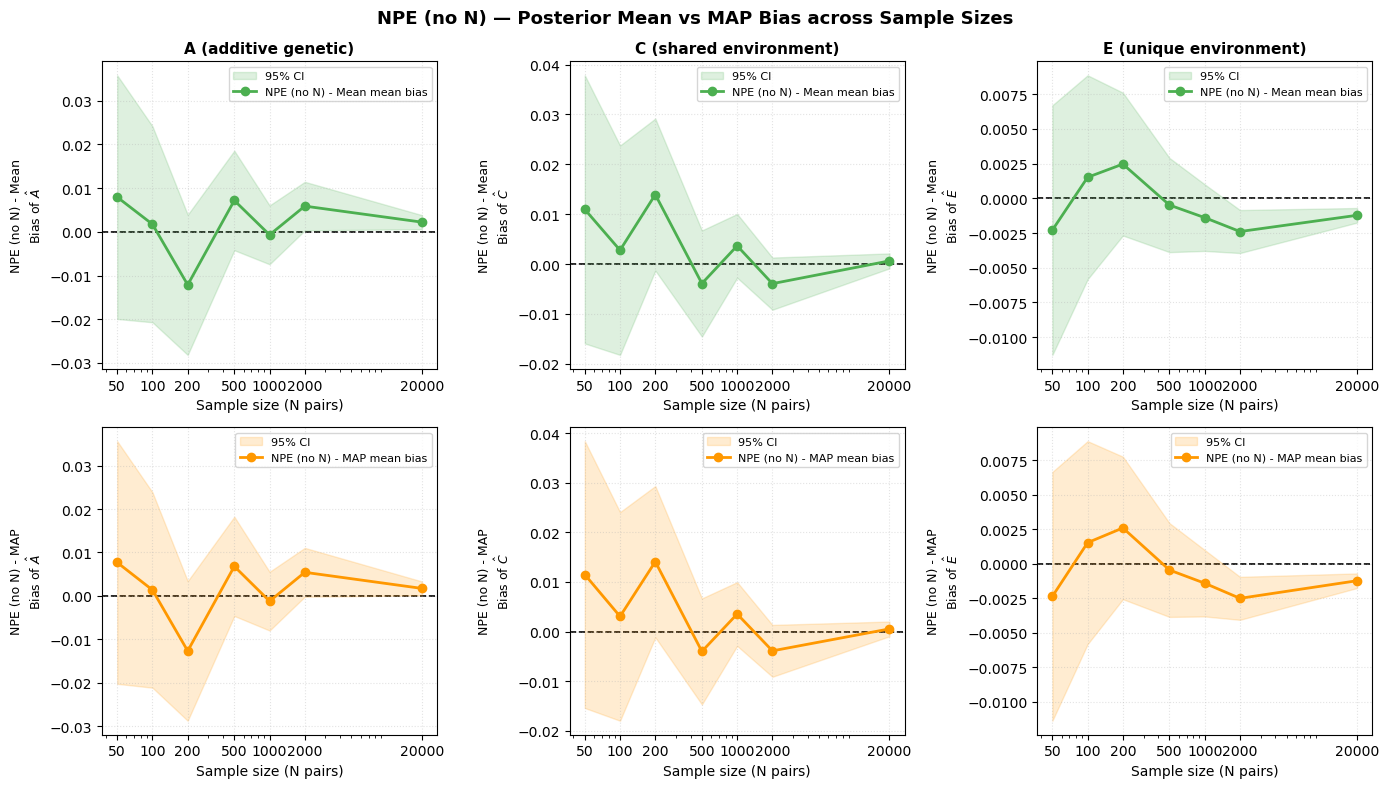


All STEP 06 outputs written to: /Users/xuly4739/Library/CloudStorage/OneDrive-UCB-O365/Documents/coding/PyProject/PGS_Cor_Relative/Scripts/nn_validate/ace_npe/results/analysis


In [18]:
# -- Posterior mean vs MAP as the point estimate (no-N model) ---------------
print("NPE (no-N) MAP bias (MAP - true) by sample size\n")
print(npe_no_n_map_bias.round(4).to_string())

bias_panel(
    [
        ("NPE (no N) - Mean", npe_no_n_bias,     npe_no_n_bias_se,     NO_N_COLOR),
        ("NPE (no N) - MAP",  npe_no_n_map_bias, npe_no_n_map_bias_se, MAP_COLOR),
    ],
    "NPE (no N) — Posterior Mean vs MAP Bias across Sample Sizes",
    "bias_mean_vs_map_no_n",
)

print(f"\nAll STEP 06 outputs written to: {ANALYSIS_DIR}")
